<a href="https://colab.research.google.com/github/Sou963/LSD-for-research/blob/main/LSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import zipfile
import os

zip_file = "archive.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

healthy_path = "dataset/healthycows"
lumpy_path = "dataset/lumpycows"

healthy_count = len(os.listdir(healthy_path))
lumpy_count = len(os.listdir(lumpy_path))

print("Healthy cows:", healthy_count)
print("Lumpy cows:", lumpy_count)
print("Total images:", healthy_count + lumpy_count)

Healthy cows: 515
Lumpy cows: 421
Total images: 936


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Classes:", train_dataset.class_names)

# Split temporary dataset into validation and test
temp_batches = tf.data.experimental.cardinality(temp_dataset)
validation_batches = temp_batches // 2

validation_dataset = temp_dataset.take(validation_batches)
test_dataset = temp_dataset.skip(validation_batches)

print("Train batches:", tf.data.experimental.cardinality(train_dataset))
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset))
print("Test batches:", tf.data.experimental.cardinality(test_dataset))

Found 936 files belonging to 2 classes.
Using 749 files for training.
Found 936 files belonging to 2 classes.
Using 187 files for validation.
Classes: ['healthycows', 'lumpycows']
Train batches: tf.Tensor(24, shape=(), dtype=int64)
Validation batches: tf.Tensor(3, shape=(), dtype=int64)
Test batches: tf.Tensor(3, shape=(), dtype=int64)


In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.6315 - loss: 0.6420 - val_accuracy: 0.5714 - val_loss: 0.7450
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.6888 - loss: 0.5875 - val_accuracy: 0.7440 - val_loss: 0.5463
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7435 - loss: 0.5089 - val_accuracy: 0.7321 - val_loss: 0.4933
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.7747 - loss: 0.4736 - val_accuracy: 0.7381 - val_loss: 0.5153
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.8086 - loss: 0.4335 - val_accuracy: 0.8274 - val_loss: 0.4441
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8034 - loss: 0.4203 - val_accuracy: 0.8095 - val_loss: 0.4070
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 989ms/step - accuracy: 0.7760 - loss: 0.4637 - val_accuracy: 0.8333 - val_loss: 0.4136
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8281 - loss: 0.4039 - val_accuracy: 0.8274 - val_lo

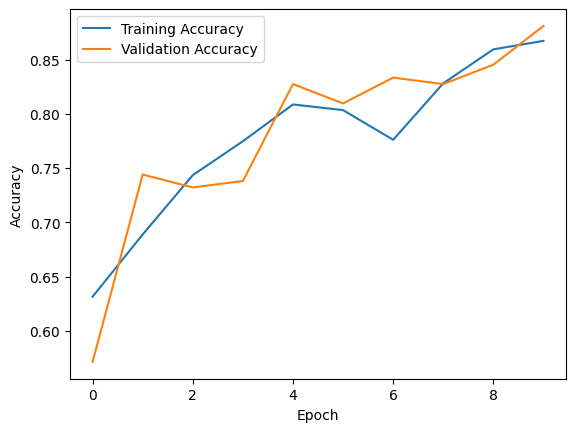

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

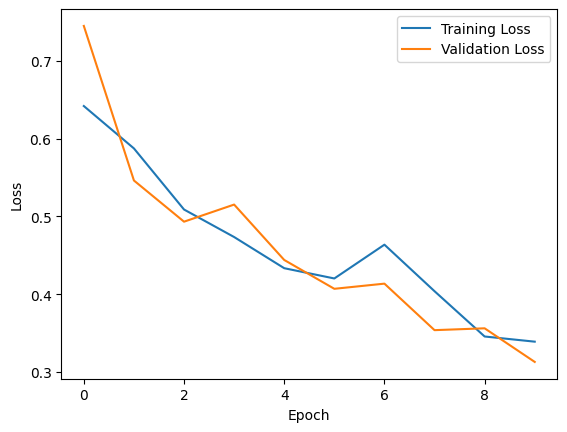

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [16]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# --- 1. Data Loading & Extraction ---
# (Assuming archive.zip is already uploaded as per your previous steps)
if os.path.exists('archive.zip'):
    with zipfile.ZipFile("archive.zip", "r") as zip_ref:
        zip_ref.extractall("dataset")
    print("Dataset extracted successfully!")

# --- 2. Dataset Preparation (80/10/10 Split) ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Initial 80% Train, 20% Temp
train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split Temp into 50% Val, 50% Test (10% total each)
temp_batches = tf.data.experimental.cardinality(temp_ds)
val_batches = temp_batches // 2
val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

class_names = ['Healthy', 'Lumpy']
print(f"Classes found: {train_ds.class_names} -> Mapped to: {class_names}")

# --- 3. Data Augmentation & Preprocessing ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# --- 4. Model Architecture ---
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False  # Freeze base

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x) # Proper MobileNetV2 scaling (-1 to 1)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x) # Regularization
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

# --- 5. Stage 1: Training Top Layers ---
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="binary_crossentropy", metrics=["accuracy"])

print("\nStarting Stage 1: Training Head...")
history_stage1 = model.fit(train_ds, validation_data=val_ds, epochs=10)

# --- 6. Stage 2: Fine-Tuning ---
base_model.trainable = True
# Freeze everything except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Small LR for fine-tuning
              loss="binary_crossentropy", metrics=["accuracy"])

print("\nStarting Stage 2: Fine-Tuning last 30 layers...")
history_stage2 = model.fit(train_ds, validation_data=val_ds, epochs=10)

# Combine histories for plotting
acc = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
val_acc = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
loss = history_stage1.history['loss'] + history_stage2.history['loss']
val_loss = history_stage1.history['val_loss'] + history_stage2.history['val_loss']

# --- 7. Evaluation ---
print("\nEvaluating on Test Set...")
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test Accuracy Percentage: {results[1]*100:.2f}%")

# Save Model
model.save("lumpy_skin_disease_mobilenetv2.keras")

# --- 8. Visualizations ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=9, color='r', linestyle='--', label='Fine-tuning Start')
plt.legend(); plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=9, color='r', linestyle='--', label='Fine-tuning Start')
plt.legend(); plt.title('Loss')
plt.show()

# --- 9. Metrics Report ---
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

Dataset extracted successfully!
Found 936 files belonging to 2 classes.
Using 749 files for training.
Found 936 files belonging to 2 classes.
Using 187 files for validation.
Classes found: ['healthycows', 'lumpycows'] -> Mapped to: ['Healthy', 'Lumpy']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Starting Stage 1: Training Head...
Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.7370 - loss: 0.5293 - val_accuracy: 0.8229 - val_loss: 0.4634
Epoch 2/10
14/24 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8260 - loss: 0.3967

KeyboardInterrupt: 

In [18]:
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=0)

print("Total Test Accuracy: {:.2f}%".format(test_accuracy * 100))

Total Test Accuracy: 84.62%


In [20]:
import tensorflow as tf
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy Percentage:", test_accuracy * 100)

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 954ms/step - accuracy: 0.8681 - loss: 0.3233
Test Loss: 0.32330790162086487
Test Accuracy: 0.8681318759918213
Test Accuracy Percentage: 86.81318759918213


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

print(classification_report(
    y_true,
    y_pred,
    target_names=["Healthy", "Lumpy"]
))

              precision    recall  f1-score   support

     Healthy       0.84      0.90      0.87        52
       Lumpy       0.86      0.77      0.81        39

    accuracy                           0.85        91
   macro avg       0.85      0.84      0.84        91
weighted avg       0.85      0.85      0.84        91



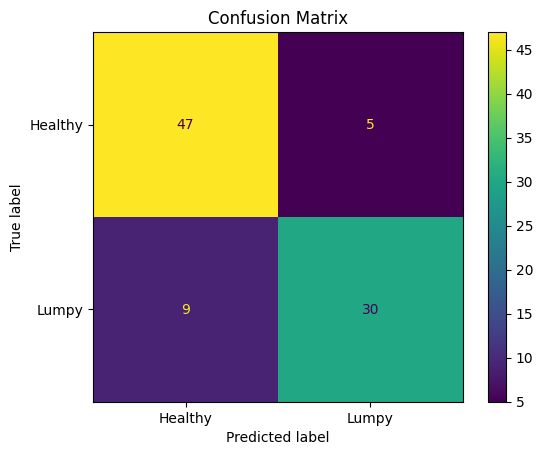

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Lumpy"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [49]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8785 - loss: 0.3370 - val_accuracy: 0.8125 - val_loss: 0.4233
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8718 - loss: 0.3202 - val_accuracy: 0.8542 - val_loss: 0.3842
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.8812 - loss: 0.3059 - val_accuracy: 0.8333 - val_loss: 0.3207
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8879 - loss: 0.2836 - val_accuracy: 0.8333 - val_loss: 0.3459
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9279 - loss: 0.2267 - val_accuracy: 0.8125 - val_loss: 0.4035
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8852 - loss: 0.2595 - val_accuracy: 0.8125 - val_loss: 0.3963
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9172 - loss: 0.2174 - val_accuracy: 0.8750 - val_loss: 0.2554
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9146 - loss: 0.2137 - val_accuracy: 0.8438 - val_loss:

In [52]:
# Combine Stage 1 + Stage 2 histories

acc = (
    history_stage1.history['accuracy']
    + history_stage2.history['accuracy']
)

val_acc = (
    history_stage1.history['val_accuracy']
    + history_stage2.history['val_accuracy']
)

loss = (
    history_stage1.history['loss']
    + history_stage2.history['loss']
)

val_loss = (
    history_stage1.history['val_loss']
    + history_stage2.history['val_loss']
)

print("Total epochs:", len(acc))
print("Final Training Accuracy:", acc[-1] * 100)
print("Final Validation Accuracy:", val_acc[-1] * 100)

Total epochs: 20
Final Training Accuracy: 96.39519453048706
Final Validation Accuracy: 84.375


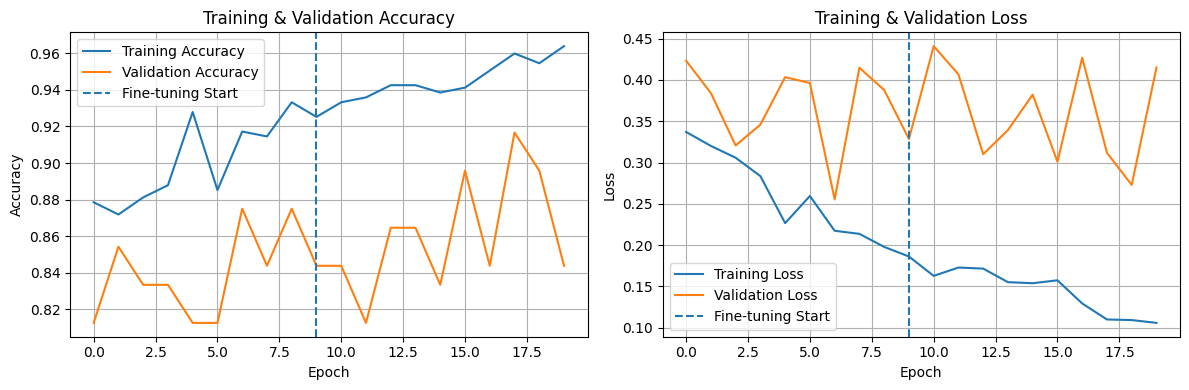

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

# Stage 2 starts after Stage 1's 10 epochs
plt.axvline(
    x=9,
    linestyle="--",
    label="Fine-tuning Start"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)

plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.axvline(
    x=9,
    linestyle="--",
    label="Fine-tuning Start"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [54]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

In [55]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [57]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [58]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [59]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.8892 - loss: 0.2403 - val_accuracy: 0.8333 - val_loss: 0.3741
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9105 - loss: 0.2057 - val_accuracy: 0.8438 - val_loss: 0.3472
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9199 - loss: 0.1924 - val_accuracy: 0.8438 - val_loss: 0.4573
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.9212 - loss: 0.1807 - val_accuracy: 0.8333 - val_loss: 0.4429
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9493 - loss: 0.1414 - val_accuracy: 0.8750 - val_loss: 0.3259
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9239 - loss: 0.1707 - val_accuracy: 0.8229 - val_loss: 0.4362
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9506 - loss: 0.1437 - val_accuracy: 0.8750 - val_loss: 0.3771
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9453 - loss: 0.1382 - val_accuracy: 0.9062 - val_loss:

In [60]:
model.save("best_lsd_model.keras")

In [61]:
model = tf.keras.models.load_model("best_lsd_model.keras")

In [62]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy Percentage:", test_accuracy * 100)

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8901 - loss: 0.2958
Test Loss: 0.29581359028816223
Test Accuracy: 0.8901098966598511
Test Accuracy Percentage: 89.01098966598511
